In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt


from uphate.numpy_interface import BootstrappedPHATE
from phate import PHATE
from uphate.uphate import (
    get_phate_embedding_bootstrap,
)
from uphate.utils import align_embeddings

In [2]:
def generate_uniform_surface_hourglass(n_samples):
    # 1. Sample 'u' uniformly
    u = np.random.uniform(0, 1, n_samples)

    # 2. Use the square root to bias points toward the wider ends
    # This accounts for the increasing surface area
    z_mag = np.sqrt(u)

    # 3. Randomly assign to the top or bottom cone
    sign = np.random.choice([-1, 1], size=n_samples)
    z = z_mag * sign

    # 4. Radius is exactly |z| for the surface
    r = np.abs(z)

    # 5. Angular component
    theta = np.random.uniform(0, 2 * np.pi, n_samples)

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    return np.vstack((x, y, z)).T


def generate_hourglass_data(n_samples=1000, target_dim=100, noise_std=0.05):
    # To project this surface to 100D:
    surface_low_dim = generate_uniform_surface_hourglass(n_samples)
    projection = np.random.randn(3, target_dim)
    surface_high_dim = (surface_low_dim @ projection) + np.random.normal(
        0, noise_std, (n_samples, target_dim)
    )

    return surface_high_dim, surface_low_dim

In [3]:
X, original_3d = generate_hourglass_data(n_samples=1000)

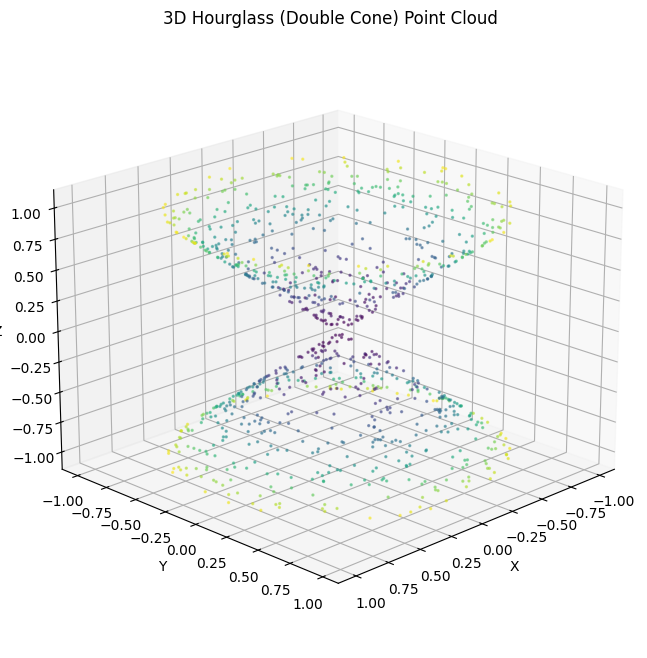

In [4]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Color by z-axis value to highlight the structure
scatter = ax.scatter(*original_3d.T, c=original_3d[:, 2] ** 2, cmap='viridis', s=2, alpha=0.5)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Hourglass (Double Cone) Point Cloud')

# Adjust view angle for perspective
ax.view_init(elev=20, azim=45)
plt.show()

In [30]:
n_components = 2
knn = 10
decay = 40
t = 25

phate_op = BootstrappedPHATE(
    n_boostrap_samples=10,
    dirichlet_alpha=0.5,
    knn=knn,
    decay=decay,
    t=t,
    n_landmark=None,
    mds_solver="smacof",
)
orig, bootstrapped = phate_op.fit_transform(X)

Calculating PHATE...
  Running PHATE on 1000 observations and 100 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.02 seconds.
    Calculating affinities...
  Calculated graph and diffusion operator in 0.03 seconds.
  Calculating Baseline embedding...
    Calculating diffusion potential...
    Calculated diffusion potential in 0.17 seconds.
    Calculating metric MDS...
    Calculated metric MDS in 2.24 seconds.
  Calculated Baseline embedding in 2.42 seconds.
  Calculating Bootstrap embedding 0...
    Calculating diffusion potential...
    Calculated diffusion potential in 0.15 seconds.
    Calculating metric MDS...
    Calculated metric MDS in 2.15 seconds.
  Calculated Bootstrap embedding 0 in 2.31 seconds.
  Calculating Bootstrap embedding 1...
    Calculating diffusion potential...
    Calculated diffusion potential in 0.14 seconds.
    Calculating metric MDS...
    Calculated metric MDS in 2.14 seconds.
  Calcul

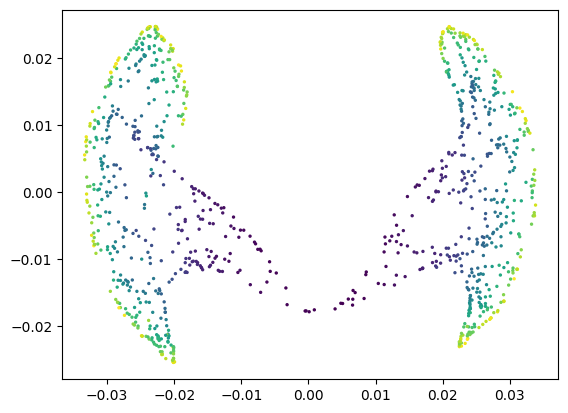

In [31]:
plt.scatter(*orig.T, c=original_3d[:, 2] ** 2, s=2)

Text(0.5, 0, 'PHATE 1')

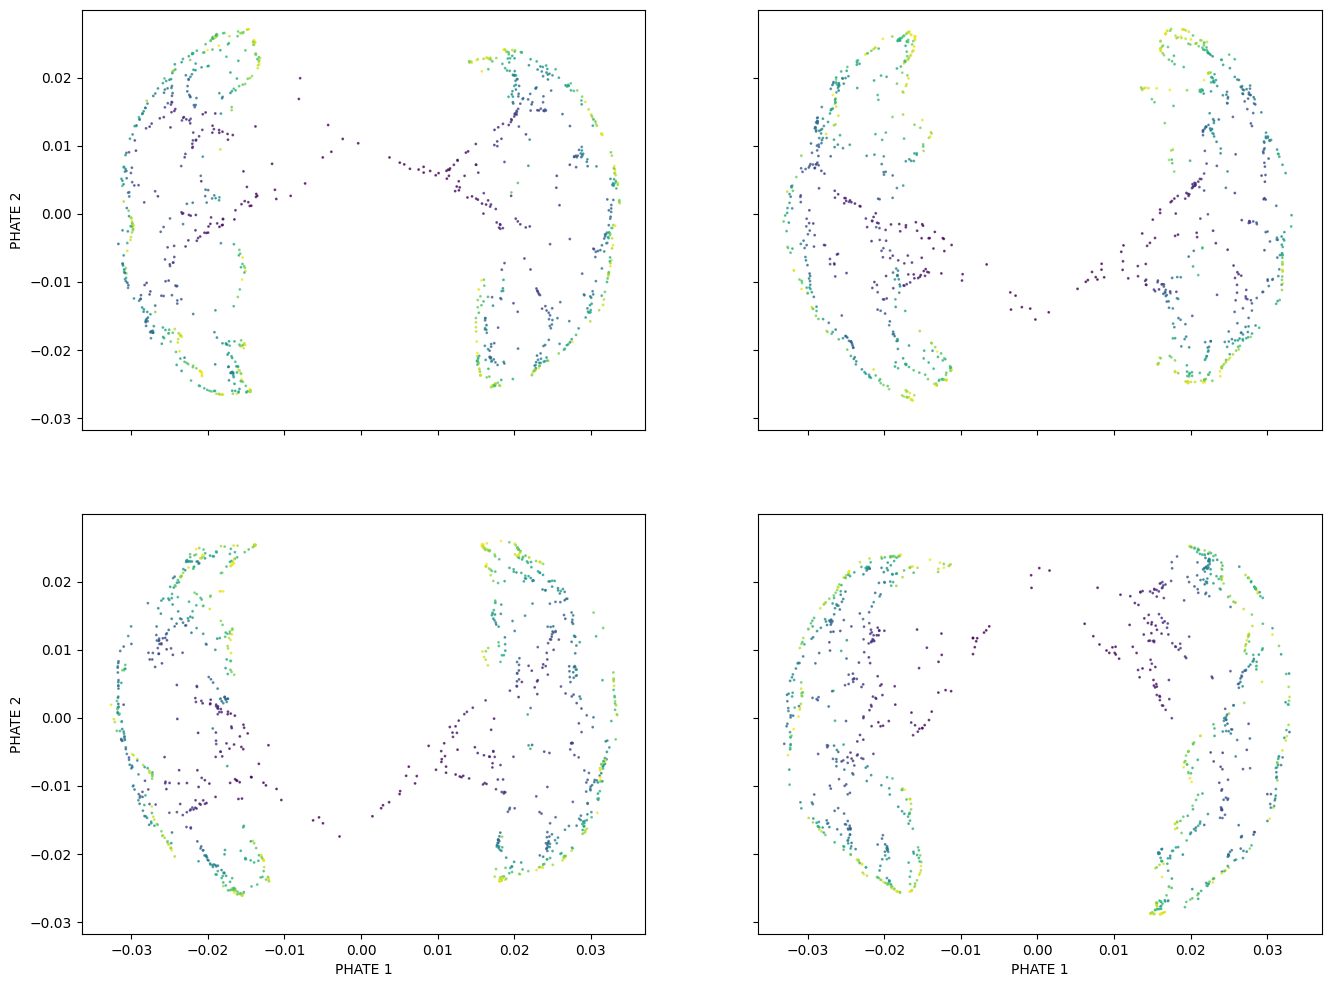

In [32]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
for ax, emb in zip(axs.flat, bootstrapped):
    #ax.scatter(*orig.T, s=0.2, c="gray")
    ax.scatter(
        *emb.T,
        s=1,
        c=original_3d[:, 2] ** 2,
        cmap="viridis",
        alpha=0.7
    )
axs[0, 0].set_ylabel("PHATE 2")
axs[1, 0].set_ylabel("PHATE 2")
axs[1, 0].set_xlabel("PHATE 1")
axs[1, 1].set_xlabel("PHATE 1")

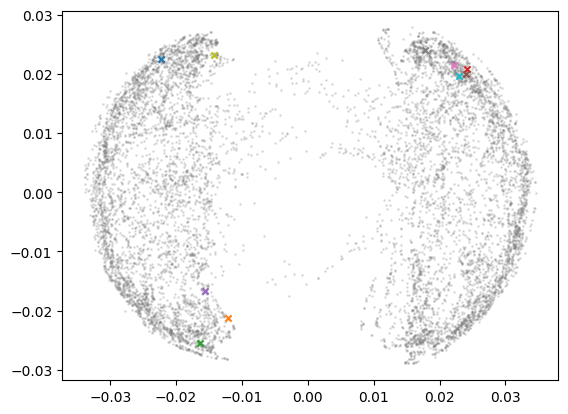

In [42]:
from random import randint

index = randint(0, len(X))

for emb in bootstrapped:
    plt.scatter(*emb.T, c="gray", alpha=0.2, s=1)

for emb in bootstrapped:
    plt.scatter(*emb[index].T, s=20, marker="x")